# $F_D$ on a slab-normal plane vs a vertical plane

At the trench the plate has begun to bend, so a vertical plane is no longer truly plate-perpendicular. The standard differential-stress resultant

$$F_D \;=\; \int_0^{z_\max}(\tau_{xx} - \tau_{zz})\,dz$$

evaluated on a vertical plane through the trench therefore mixes plate-parallel and plate-perpendicular stress components. Here we recompute $F_D$ on a **truly slab-normal plane** and compare.

**Steps.** (1) estimate the local dip $\theta$ from the angle of an isotherm in the lithosphere interior near the trench; (2) build a slab-normal integration path from the trench surface point in direction $(-\sin\theta, \cos\theta)$; (3) sample $\tau_{xx}, \tau_{zz}, \tau_{xz}$ along that path; (4) rotate the deviatoric stress into slab coordinates $(\xi, \eta)$ where $\xi$ is slab-parallel and $\eta$ is slab-perpendicular:

$$\tau_{\xi\xi} - \tau_{\eta\eta} \;=\; (\tau_{xx} - \tau_{zz})\cos 2\theta + 2\tau_{xz}\sin 2\theta$$

(5) integrate along $\eta$.

Setup duplicates `cerpa_single_step.ipynb` (config, helpers, grid) so `MODEL_KEY` and `TIMESTEP_INDEX` work the same way.

## 1. Setup & imports

In [16]:
import numpy as np
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

Same as `cerpa_single_step.ipynb`. Change `MODEL_KEY` / `TIMESTEP_INDEX` to swap.

In [26]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY      = 'WAL'
TIMESTEP_INDEX = 20

DX        = 500.0
Z_MAX     = 100_000.0
Y_SURFACE = 2_900_000.0

fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
i = TIMESTEP_INDEX if TIMESTEP_INDEX >= 0 else len(pvtu_files) + TIMESTEP_INDEX
ff = pvtu_files[i]
print(f"Model {MODEL_KEY!r} timestep {i}: {ff.split('/')[-1]}")

Model 'WAL' timestep 20: subduction_with_LM_20.pvtu


## 3. Helpers

`get_field` reshapes a sampled VTK array onto the regular grid. The 3-step trench picker (and its sub-helpers) is duplicated from `cerpa_single_step.ipynb`.

In [27]:
def get_field(name):
    f = interp[name].reshape((nx_pv, nz_pv), order='F')
    f[~valid] = np.nan
    return f.T  # (z, x)

In [28]:
def moving_average_1d(y, k):
    if k <= 1: return y
    if k % 2 == 0: k += 1
    kernel = np.ones(k) / k
    return np.convolve(y, kernel, mode='same')


def pick_trench_3step(x, z, p, vx,
        p_depth_m=0.0, vx_depth_m=5_000.0,
        Wp1_km=800.0, Wv_km=800.0, Wp3_km=300.0,
        expected_offset_km=50.0, smooth_km=20.0,
        subducting_side='left'):
    iz_p  = 0 if p_depth_m == 0.0 else int(np.argmin(np.abs(z - p_depth_m)))
    iz_vx = int(np.argmin(np.abs(z - vx_depth_m)))
    p_row, vx_row = p[iz_p, :].copy(), vx[iz_vx, :].copy()

    j0 = int(np.nanargmin(p_row));  x_p0 = float(x[j0])

    Wv = Wv_km * 1000.0
    in_v = (x >= x_p0 - Wv) & (x <= x_p0 + Wv)
    x_vw, vx_vw = x[in_v], vx_row[in_v]
    dx = np.median(np.diff(x))
    k = max(1, int((smooth_km*1000.0)/dx)); k += (k%2 == 0)
    vx_s = np.convolve(vx_vw, np.ones(k)/k, mode='same')
    s = np.sign(vx_s); s[s == 0] = np.nan
    cross = np.where(np.isfinite(s[:-1]) & np.isfinite(s[1:]) & (s[:-1]*s[1:] < 0))[0]
    if cross.size == 0:
        x_v = float(x_vw[int(np.nanargmin(np.abs(vx_s)))])
    else:
        xc = []
        for ii in cross:
            x1, x2 = x_vw[ii], x_vw[ii+1]
            v1, v2 = vx_s[ii], vx_s[ii+1]
            xc.append(x1 - v1 * (x2 - x1) / (v2 - v1))
        x_v = float(np.min(np.array(xc)))   # leftmost crossing — same rule as the other notebook

    Wp3 = Wp3_km * 1000.0
    expected_offset = expected_offset_km * 1000.0
    if subducting_side == 'left':
        mask = (x < x_v) & (x >= x_v - Wp3)
        x_expected = x_v - expected_offset
    else:
        mask = (x > x_v) & (x <= x_v + Wp3)
        x_expected = x_v + expected_offset
    xw, pw = x[mask], p_row[mask]
    good = np.isfinite(pw); xw, pw = xw[good], pw[good]
    is_min = (pw[1:-1] < pw[:-2]) & (pw[1:-1] < pw[2:])
    idx = np.where(is_min)[0] + 1
    if idx.size == 0:
        trench_x = float(xw[int(np.argmin(pw))])
    else:
        j = idx[np.argmin(np.abs(xw[idx] - x_expected))]
        trench_x = float(xw[j])

    return trench_x, dict(x_p0=x_p0, x_v=x_v)

## 4. Load PVTU and build the regular grid

Sample the unstructured Fluidity output onto a uniform `DX`-spaced grid; extract $T$, $p$, $\tau_{xx}, \tau_{zz}, \tau_{xz}$, and $v_x$ as 2-D arrays indexed `[z, x]`.

In [29]:
vtk_data = pv.read(ff)
vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
vtk_data.point_data['txz'] = vtk_data['NormalSP::Stress'][:, 1]
vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
vtk_data.point_data['vx']  = vel[:, 0]
vtk_data.point_data['vy']  = vel[:, 1]

x_min, x_max, _, _, _, _ = vtk_data.bounds
nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
x = x_min + (np.arange(nx) + 0.5) * DX
z = (np.arange(nz) + 0.5) * DX
X, Z = np.meshgrid(x, z, indexing='xy')
Y = Y_SURFACE - Z
grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
interp = grid.sample(vtk_data)
nx_pv, nz_pv, _ = interp.dimensions
valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)

p   = get_field('p')
txx = get_field('txx')
tzz = get_field('tzz')
txz = get_field('txz')
T   = get_field('T')
vx  = get_field('vx')
print(f'grid: {p.shape}  x ∈ [{x[0]/1e3:.0f}, {x[-1]/1e3:.0f}] km, z ∈ [{z[0]/1e3:.1f}, {z[-1]/1e3:.1f}] km')

grid: (200, 15999)  x ∈ [0, 7999] km, z ∈ [0.2, 99.8] km


## 5. Trench identification

In [30]:
tloc, info = pick_trench_3step(
    x, z, p, vx,
    vx_depth_m=5000, Wv_km=800, Wp3_km=800,
    smooth_km=40, subducting_side='left',
)
tindx = int(np.argmin(np.abs(x - tloc)))
print(f'Trench at x = {tloc/1e3:.1f} km (index {tindx})')

Trench at x = 3262.8 km (index 6525)


## 6. Slab dip from interior isotherm

Pick an isotherm well inside the lithosphere (`T_ISO ~ 600-800°C`). For each $x$ in a symmetric window of half-width `WINDOW_KM` around the trench, find the depth where $T(x, z) = T_\mathrm{iso}$ and fit a line to those points. The slope gives $\tan\theta$.

In [53]:
T_ISO     = 800.0   # °C — middle of lithosphere
WINDOW_KM = 10      # half-width of symmetric window (± WINDOW_KM around trench)

x_lo = tloc - WINDOW_KM * 1000.0
x_hi = tloc + WINDOW_KM * 1000.0
ix_window = np.where((x >= x_lo) & (x <= x_hi))[0]

z_iso = []
for ix in ix_window:
    Tcol = T[:, ix]
    if not np.all(np.isfinite(Tcol)) or T_ISO <= Tcol[0] or T_ISO >= Tcol[-1]:
        z_iso.append(np.nan)
        continue
    z_iso.append(np.interp(T_ISO, Tcol, z))
z_iso = np.array(z_iso)
x_window = x[ix_window]

good = np.isfinite(z_iso)
m, b = np.polyfit(x_window[good], z_iso[good], 1)
dip = float(np.arctan(m))   # in radians
print(f'Slab dip from {T_ISO:.0f}°C isotherm (over ±{WINDOW_KM} km around trench): {np.rad2deg(dip):.2f}°')
print(f'  isotherm depth at trench  ≈ {b + m*tloc:7.0f} m  ({(b + m*tloc)/1e3:.1f} km)')

Slab dip from 800°C isotherm (over ±10 km around trench): 3.08°
  isotherm depth at trench  ≈   32767 m  (32.8 km)


## 7. Build slab-normal integration path and sample stresses

Slab-normal direction (into the rock from the surface): $\hat{\eta} = (-\sin\theta, \cos\theta)$. Path starts at the trench surface point and steps along $\hat{\eta}$ for length $L$.

In [54]:
L_PATH = Z_MAX             # length along slab-normal path (m); same as vertical extent
DS     = 100.0             # step size along path (m)

n_steps = int(L_PATH / DS) + 1
s_path = np.arange(n_steps) * DS

nx_hat = -np.sin(dip)      # slab-normal direction
nz_hat = +np.cos(dip)

x_path = tloc + s_path * nx_hat
z_path = z[0] + s_path * nz_hat   # start at first row of grid (z = 500 m), not z = 0

# Interpolate stresses along the path
def make_interp(field):
    return RegularGridInterpolator((z, x), field, bounds_error=False, fill_value=np.nan)

fT   = make_interp(T)
ftxx = make_interp(txx)
ftzz = make_interp(tzz)
ftxz = make_interp(txz)

pts = np.column_stack([z_path, x_path])
T_path   = fT(pts)
txx_path = ftxx(pts)
tzz_path = ftzz(pts)
txz_path = ftxz(pts)

# Rotated differential stress: τ_ξξ - τ_ηη
two_theta = 2 * dip
diff_rotated  = (txx_path - tzz_path) * np.cos(two_theta) + 2 * txz_path * np.sin(two_theta)
diff_vertical = txx[:, tindx] - tzz[:, tindx]   # along the vertical column

## 8. $F_D$ — vertical vs slab-normal


F_D on vertical   plane:   -1.894  TN/m
F_D on slab-normal plane:  -2.205  TN/m
difference:  -0.311  TN/m
(slab-normal − vertical) / vertical = +16.4 %


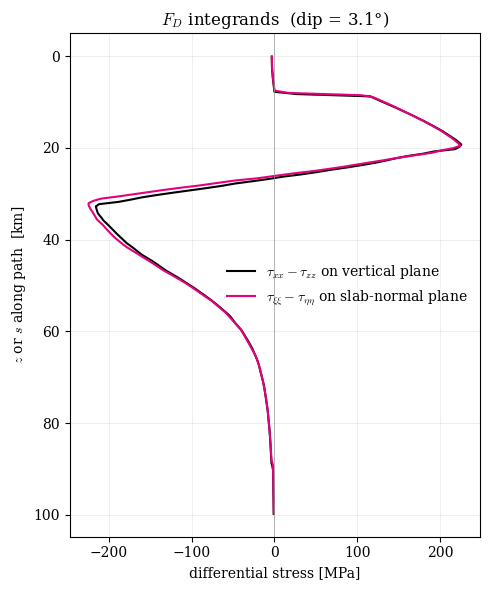

In [55]:
F_D_vertical    = np.trapz(diff_vertical, z)
F_D_slab_normal = np.trapz(diff_rotated[np.isfinite(diff_rotated)],
                            s_path[np.isfinite(diff_rotated)])

print(f'F_D on vertical   plane:  {F_D_vertical    * 1e-12:+7.3f}  TN/m')
print(f'F_D on slab-normal plane: {F_D_slab_normal * 1e-12:+7.3f}  TN/m')
print(f'difference: {(F_D_slab_normal - F_D_vertical)*1e-12:+7.3f}  TN/m')
print(f'(slab-normal − vertical) / vertical = {(F_D_slab_normal/F_D_vertical - 1)*100:+.1f} %' if F_D_vertical != 0 else '')

# Plot the integrand on each path so you can see WHERE F_D comes from
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(diff_vertical*1e-6, z*1e-3, 'k-', lw=1.5, label=r'$\tau_{xx}-\tau_{zz}$ on vertical plane')
ax.plot(diff_rotated *1e-6, s_path*1e-3, color='#E5007D', lw=1.5,
        label=r'$\tau_{\xi\xi}-\tau_{\eta\eta}$ on slab-normal plane')
ax.axvline(0, color='0.6', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('differential stress [MPa]')
ax.set_ylabel(r'$z$ or $s$ along path  [km]')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
ax.set_title(f'$F_D$ integrands  (dip = {np.rad2deg(dip):.1f}°)')
fig.tight_layout()
plt.show()

## 9. Visualisation — verify the path orientation

Zoomed view of the trench region with: temperature field as background, the chosen isotherm (gold), the linear dip fit (dashed), the vertical line and the slab-normal path. Use this to confirm the slab-normal path actually follows the lithosphere.

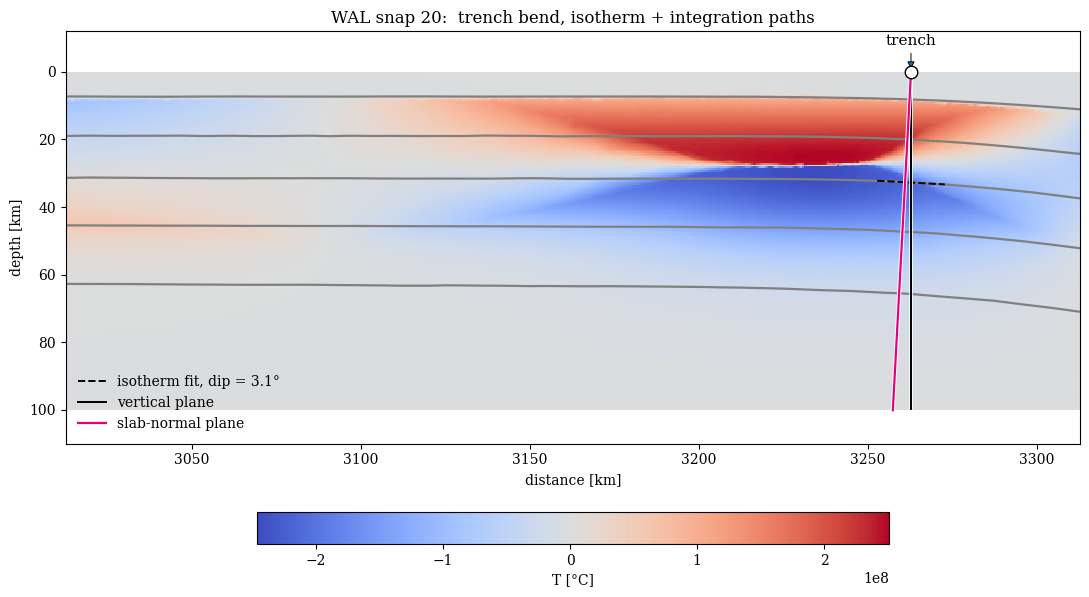

In [57]:
WIN_X_KM = 250
WIN_Z_KM = 110
x_lo_v = tloc - WIN_X_KM * 1e3
x_hi_v = tloc + 50e3
ix_v   = (x >= x_lo_v) & (x <= x_hi_v)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.pcolormesh(x[ix_v]*1e-3, z*1e-3, txx[:, ix_v] - tzz[:, ix_v],
                   cmap='coolwarm', shading='auto')
cbar = fig.colorbar(im, ax=ax, label='T [°C]', orientation='horizontal',
                    fraction=0.06, pad=0.13)

ax.contour(x[ix_v]*1e-3, z*1e-3, T[:, ix_v], levels=[400, 600, 800, 1000, 1200],
           colors='grey', linewidths=1.6)

x_fit = np.linspace(x_window.min(), x_window.max(), 60)
ax.plot(x_fit*1e-3, (m*x_fit + b)*1e-3, 'k--', lw=1.4,
        label=f'isotherm fit, dip = {np.rad2deg(dip):.1f}°')

# Vertical integration line
ax.plot([tloc*1e-3, tloc*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='white', lw=2.6)
ax.plot([tloc*1e-3, tloc*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='black', lw=1.4, label='vertical plane')

# Slab-normal path
ax.plot(x_path*1e-3, z_path*1e-3, color='white', lw=3.0)
ax.plot(x_path*1e-3, z_path*1e-3, color='#E5007D', lw=1.6, label='slab-normal plane')

# Trench marker
ax.plot(tloc*1e-3, 0, 'wo', mec='k', ms=9, zorder=5)
ax.annotate('trench', xy=(tloc*1e-3, 0), xytext=(tloc*1e-3, -8),
            ha='center', fontsize=11,
            arrowprops=dict(arrowstyle='-|>', lw=0.7))

ax.invert_yaxis()
ax.set_xlim(x_lo_v*1e-3, x_hi_v*1e-3)
ax.set_ylim(WIN_Z_KM, -12)
ax.set_xlabel('distance [km]')
ax.set_ylabel('depth [km]')
ax.set_aspect('equal')
ax.legend(loc='lower left', frameon=False, fontsize=10)
ax.set_title(f'{MODEL_KEY} snap {TIMESTEP_INDEX}:  trench bend, isotherm + integration paths')
fig.tight_layout()

figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'slab_normal_path_{MODEL_KEY}_t{TIMESTEP_INDEX}.png',
            bbox_inches='tight', dpi=200)
plt.show()

In [ ]:
#F_D on vertical   plane:   -1.894  TN/m
#F_D on slab-normal plane:  -2.199  TN/m

In [51]:
-2.199*np.cos(np.deg2rad(3))

-2.1959863469253076